### Notebook 03 — Exploratory Data Analysis
#### Market Pulse Analytics

**Charts produced:**
1. Normalized price performance by sector (5-year)
2. Annual sector returns heatmap
3. Rolling volatility comparison
4. Daily returns correlation matrix
5. Risk vs Return scatter plot

In [4]:
# CELL 2 — Imports and Setup

import os
import sys
import warnings

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath(".."))
from config.settings import PROCESSED_DATA_PATH

# ── Plot Theme ────────────────────────────────────────────────

plt.rcParams.update({
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#161b22",
    "axes.edgecolor":    "#30363d",
    "axes.labelcolor":   "#c9d1d9",
    "axes.titlecolor":   "#e6edf3",
    "text.color":        "#c9d1d9",
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "grid.color":        "#21262d",
    "grid.alpha":        0.6,
    "legend.facecolor":  "#161b22",
    "legend.edgecolor":  "#30363d",
    "figure.dpi":        130,
    "font.family":       "sans-serif",
})

SECTOR_COLORS = {
    "Technology": "#58a6ff",
    "Financials": "#3fb950",
    "Healthcare": "#f78166",
    "Energy":     "#d2a8ff",
    "Consumer":   "#ffa657",
}

TICKER_COLORS = {
    "AAPL": "#58a6ff", "MSFT": "#79c0ff", "GOOGL": "#cae8ff",
    "JPM":  "#3fb950", "GS":   "#56d364", "BAC":   "#7ee787",
    "JNJ":  "#f78166", "PFE":  "#ffa198", "XOM":   "#d2a8ff",
    "CVX":  "#bc8cff", "AMZN": "#ffa657", "WMT":   "#ffcf7d",
}

daily_df = pd.read_csv(f'../{PROCESSED_DATA_PATH}daily_features.csv',
                          parse_dates=["date"])
monthly_df = pd.read_csv(f"../{PROCESSED_DATA_PATH}monthly_summary.csv")
sector_df  = pd.read_csv(f"../{PROCESSED_DATA_PATH}sector_monthly.csv")

print(f"✓ daily_df   : {daily_df.shape}")
print(f"✓ monthly_df : {monthly_df.shape}")
print(f"✓ sector_df  : {sector_df.shape}")

✓ daily_df   : (19272, 34)
✓ monthly_df : (924, 26)
✓ sector_df  : (385, 14)


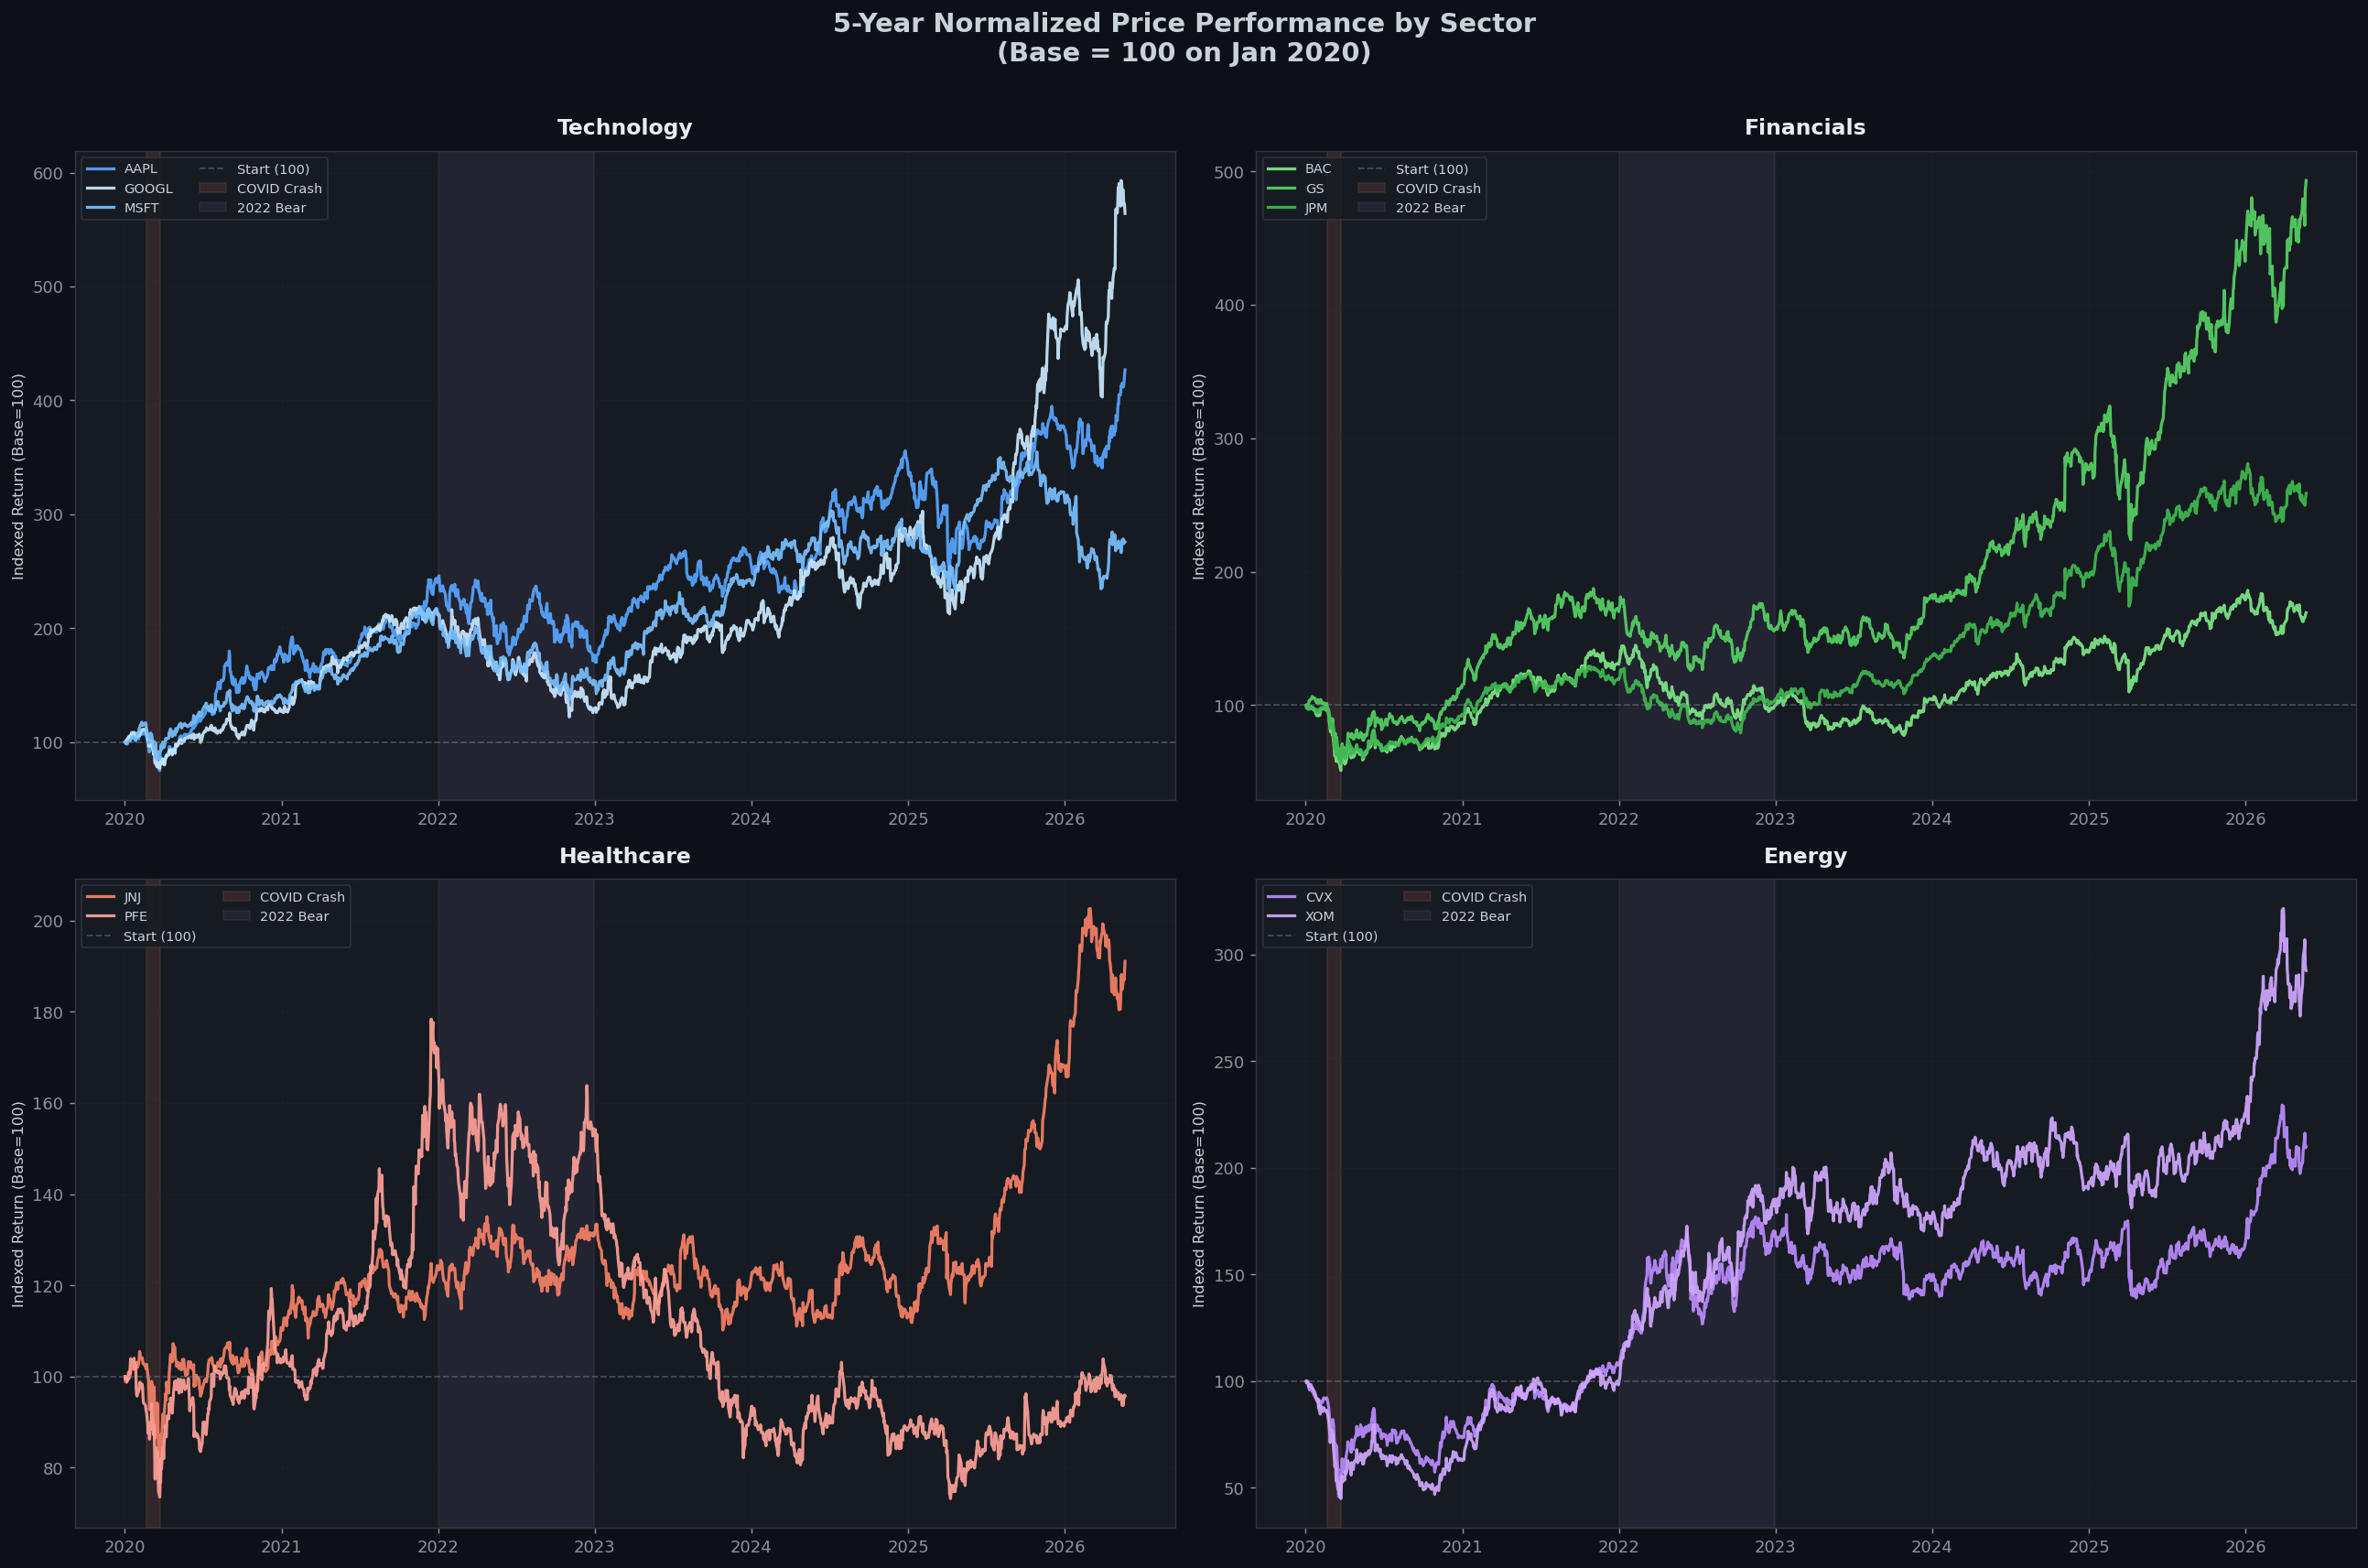

In [6]:
# CHART 1 — Normalized Price Performance by Sector

fig, axes = plt.subplots(2, 2, figsize = (20,13))
fig.suptitle('5-Year Normalized Price Performance by Sector\n(Base = 100 on Jan 2020)',
             fontsize =16, fontweight = 'bold', y = 1.01)

sectors = ["Technology", "Financials", "Healthcare", "Energy"]

for ax, sector in zip(axes.flatten(), sectors):
    
    sector_tickers = (
        daily_df[daily_df['sector'] == sector]['ticker'].unique()
    )

    for ticker in sector_tickers:
        
        data = (daily_df[daily_df['ticker'] == ticker]).sort_values('date')

        # Normalize: set first value = 100
        normalized = (data["close"] / data["close"].iloc[0]) * 100
        
        ax.plot(
            data['date'],
            normalized,
            label = ticker,
            color = TICKER_COLORS.get(ticker, '#ffffff'),
            linewidth = 1.8,
            alpha = 0.92
        )

    # Reference line at 100 (break-even)

    ax.axhline(
        100, color = '#8b949e', linestyle = '--',
        alpha = 0.4, linewidth = 1, label = 'Start (100)'
    )

    # Shade COVID crash
    ax.axvspan(
        pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'),
        alpha = 0.12, color = '#f78166', label = 'COVID Crash')

    # Shade 2022 bear market
    ax.axvspan(
        pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
        alpha=0.07, color="#d2a8ff", label="2022 Bear"
    )

    ax.set_title(f'{sector}', fontweight = 'bold', fontsize = 13, pad = 10)
    ax.set_ylabel('Indexed Return (Base=100)', fontsize = 9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=8, loc="upper left", ncol=2)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor("#161b22")

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig(
    "../reports/chart1_normalized_performance.png",
    dpi=150, bbox_inches="tight", facecolor="#0d1117"
)
plt.show()

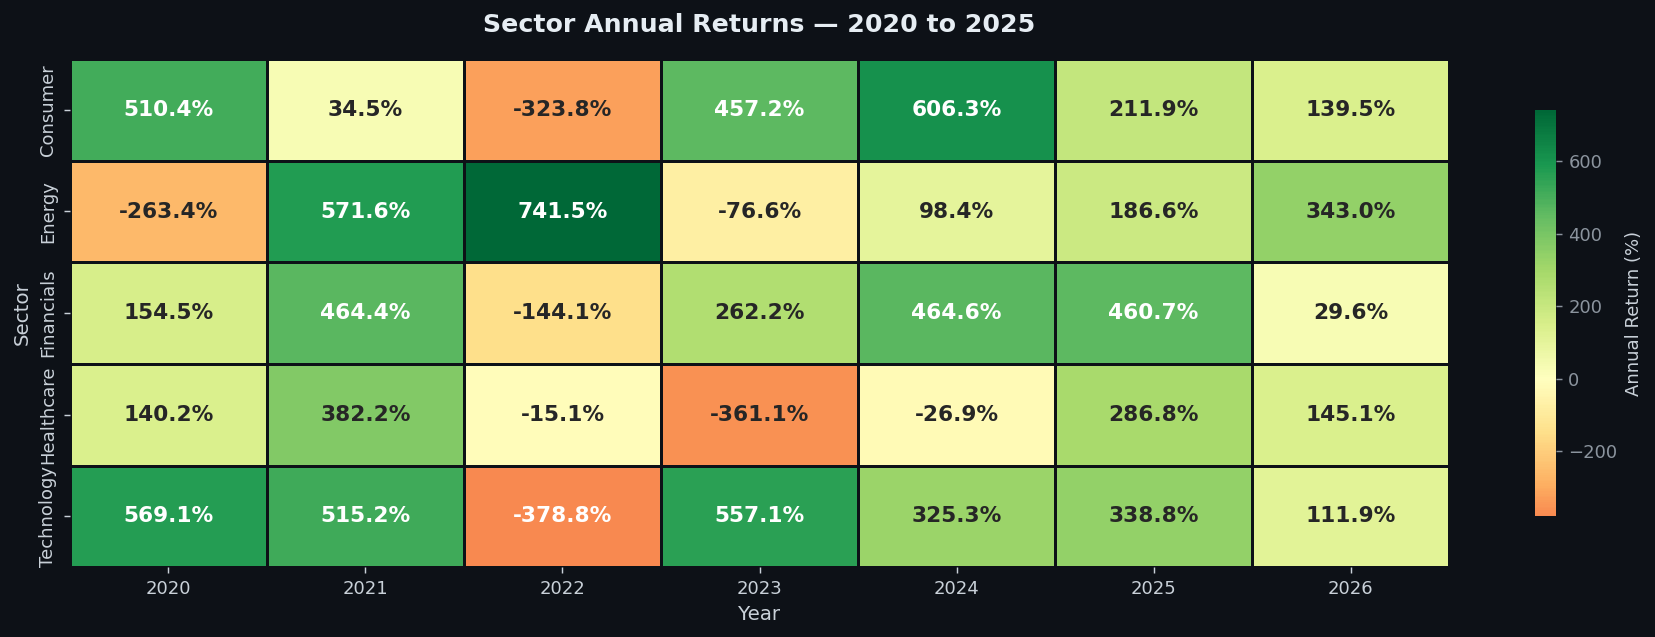


--- Annual Returns Table (%) ---
year          2020    2021    2022    2023    2024    2025    2026
sector                                                            
Consumer    510.40   34.52 -323.77  457.25  606.26  211.91  139.51
Energy     -263.37  571.61  741.51  -76.58   98.36  186.58  343.02
Financials  154.53  464.39 -144.14  262.16  464.56  460.66   29.64
Healthcare  140.16  382.16  -15.07 -361.07  -26.89  286.80  145.08
Technology  569.07  515.16 -378.76  557.07  325.33  338.81  111.86


In [7]:
# CHART 2 — Annual Returns Heatmap by Sector

# Calculate annual return per sector
# Sum of average daily returns × 252 trading days = approximate annual return
annual_data = (
    sector_df
    .groupby(["sector", "year"])["avg_daily_return"]
    .sum()
    .reset_index()
)

annual_data["annual_return_pct"] = (annual_data["avg_daily_return"] * 252).round(2)

pivot = annual_data.pivot(
    index="sector",
    columns="year",
    values="annual_return_pct"
)

fig, ax = plt.subplots(figsize = (14,5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor("#0d1117")

hm = sns.heatmap(
    pivot,
    annot=True,
    fmt = '.1f',
    cmap = 'RdYlGn',
    center=0,
    linewidths = 0.8,
    linecolor = '#0d1117',
    ax = ax,
    cbar_kws = {"label": "Annual Return (%)", "shrink": 0.8},
    annot_kws={"size": 12, "weight": "bold"}
)

# Add % to annotations
for text in ax.texts:
    val = text.get_text()
    if val not in ["", "nan"]:
        text.set_text(val + "%")

ax.set_title(
    "Sector Annual Returns — 2020 to 2025",
    fontsize=14, fontweight="bold", pad=15,
    color="#e6edf3"
)

ax.set_xlabel("Year",   fontsize=11, color="#c9d1d9")
ax.set_ylabel("Sector", fontsize=11, color="#c9d1d9")
ax.tick_params(colors="#c9d1d9", labelsize=10)

plt.tight_layout()
plt.savefig(
    "../reports/chart2_annual_heatmap.png",
    dpi=150, bbox_inches="tight", facecolor="#0d1117"
)
plt.show()

print("\n--- Annual Returns Table (%) ---")
print(pivot.to_string())

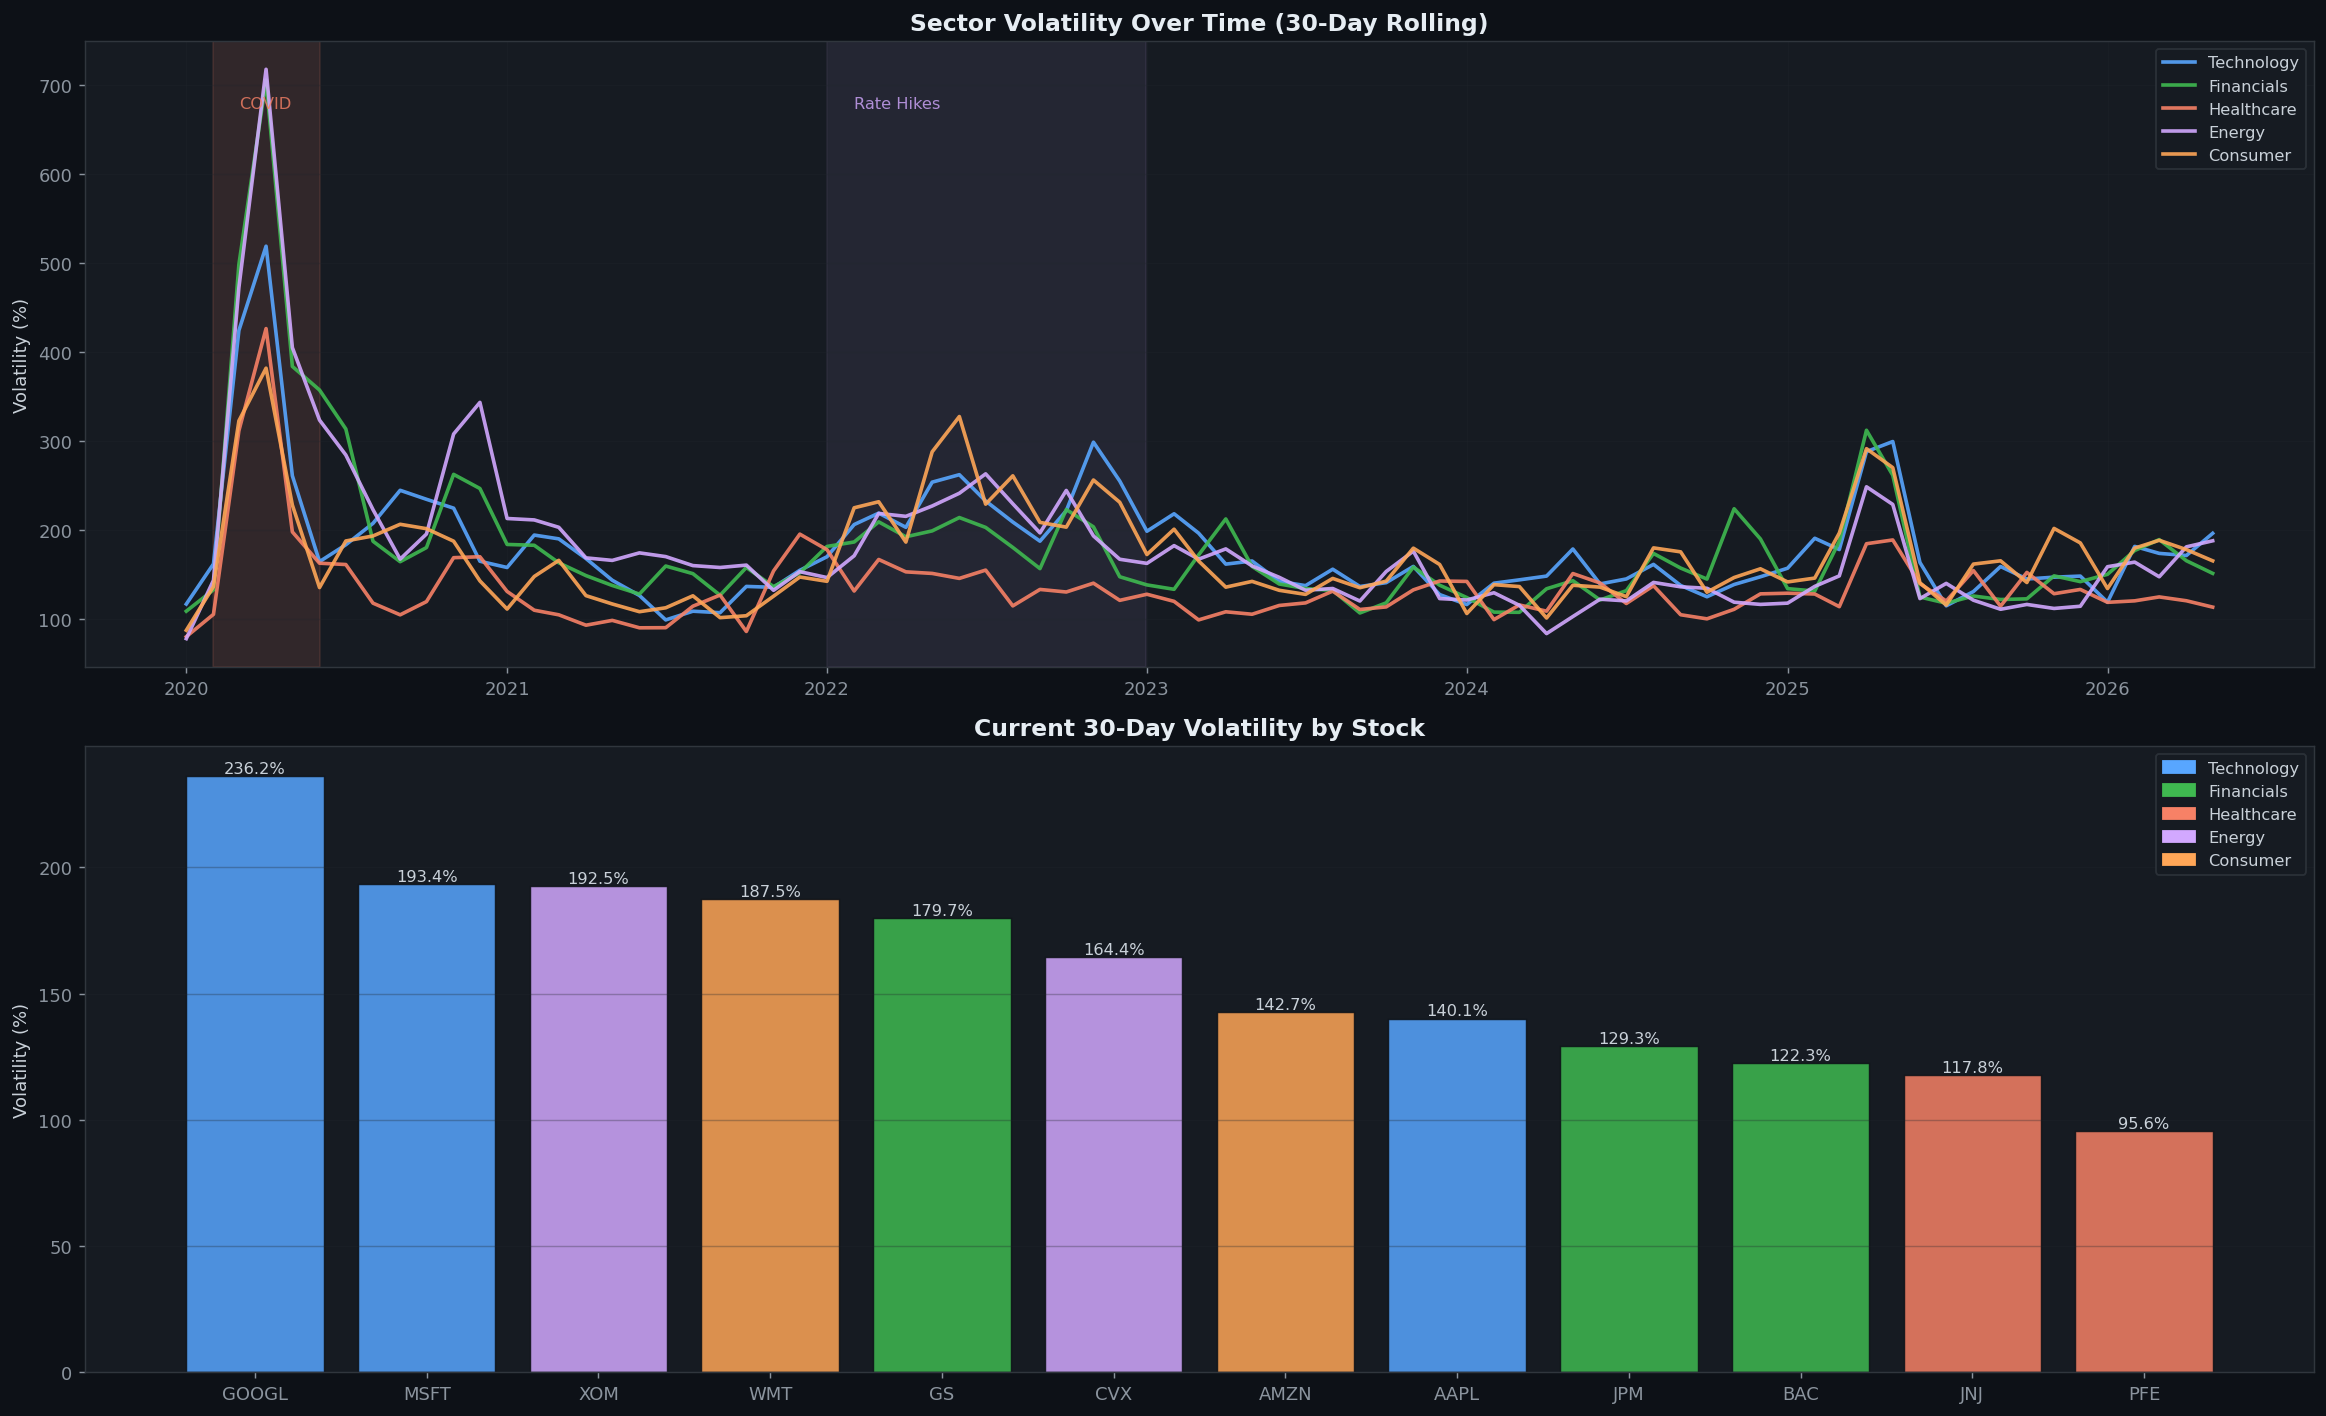

In [8]:
# CHART 3 — Volatility Analysis

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 11), facecolor="#0d1117")

# ── Top: Volatility over time ─────────────────────────────────
sector_df["date_parsed"] = pd.to_datetime(
    sector_df["year"].astype(str) + "-" +
    sector_df["month"].astype(str).str.zfill(2) + "-01"
)

for sector in SECTOR_COLORS:
    sdata = (sector_df[sector_df["sector"] == sector]
             .sort_values("date_parsed"))
    if sdata.empty:
        continue
    ax1.plot(
        sdata["date_parsed"],
        sdata["avg_volatility"] * 100,
        label=sector,
        color=SECTOR_COLORS[sector],
        linewidth=2.0,
        alpha=0.9
    )

ax1.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"),
            alpha=0.12, color="#f78166")
ax1.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
            alpha=0.08, color="#d2a8ff")

ax1.text(pd.Timestamp("2020-03-01"), ax1.get_ylim()[1] * 0.9,
         "COVID", color="#f78166", fontsize=9, alpha=0.8)
ax1.text(pd.Timestamp("2022-02-01"), ax1.get_ylim()[1] * 0.9,
         "Rate Hikes", color="#d2a8ff", fontsize=9, alpha=0.8)

ax1.set_title("Sector Volatility Over Time (30-Day Rolling)",
              fontsize=13, fontweight="bold", color="#e6edf3")
ax1.set_ylabel("Volatility (%)", fontsize=10, color="#c9d1d9")
ax1.legend(fontsize=9, loc="upper right")
ax1.grid(True, alpha=0.3)
ax1.set_facecolor("#161b22")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Bottom: Current volatility by ticker ──────────────────────
latest_vol = (daily_df
              .sort_values("date")
              .groupby("ticker")
              .last()
              .reset_index()[["ticker", "sector", "volatility_30d"]])

latest_vol["vol_pct"] = (latest_vol["volatility_30d"] * 100).round(2)
latest_vol = latest_vol.sort_values("vol_pct", ascending=False)

bar_colors = [SECTOR_COLORS.get(s, "#ffffff") for s in latest_vol["sector"]]
bars = ax2.bar(
    latest_vol["ticker"],
    latest_vol["vol_pct"],
    color=bar_colors,
    alpha=0.85,
    edgecolor="#0d1117",
    linewidth=0.8
)

for bar, val in zip(bars, latest_vol["vol_pct"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.1f}%",
        ha="center", va="bottom", fontsize=9, color="#c9d1d9"
    )

ax2.set_title("Current 30-Day Volatility by Stock",
              fontsize=13, fontweight="bold", color="#e6edf3")
ax2.set_ylabel("Volatility (%)", fontsize=10, color="#c9d1d9")
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_facecolor("#161b22")

legend_patches = [
    mpatches.Patch(color=v, label=k)
    for k, v in SECTOR_COLORS.items()
]
ax2.legend(handles=legend_patches, fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(
    "../reports/chart3_volatility.png",
    dpi=150, bbox_inches="tight", facecolor="#0d1117"
)
plt.show()

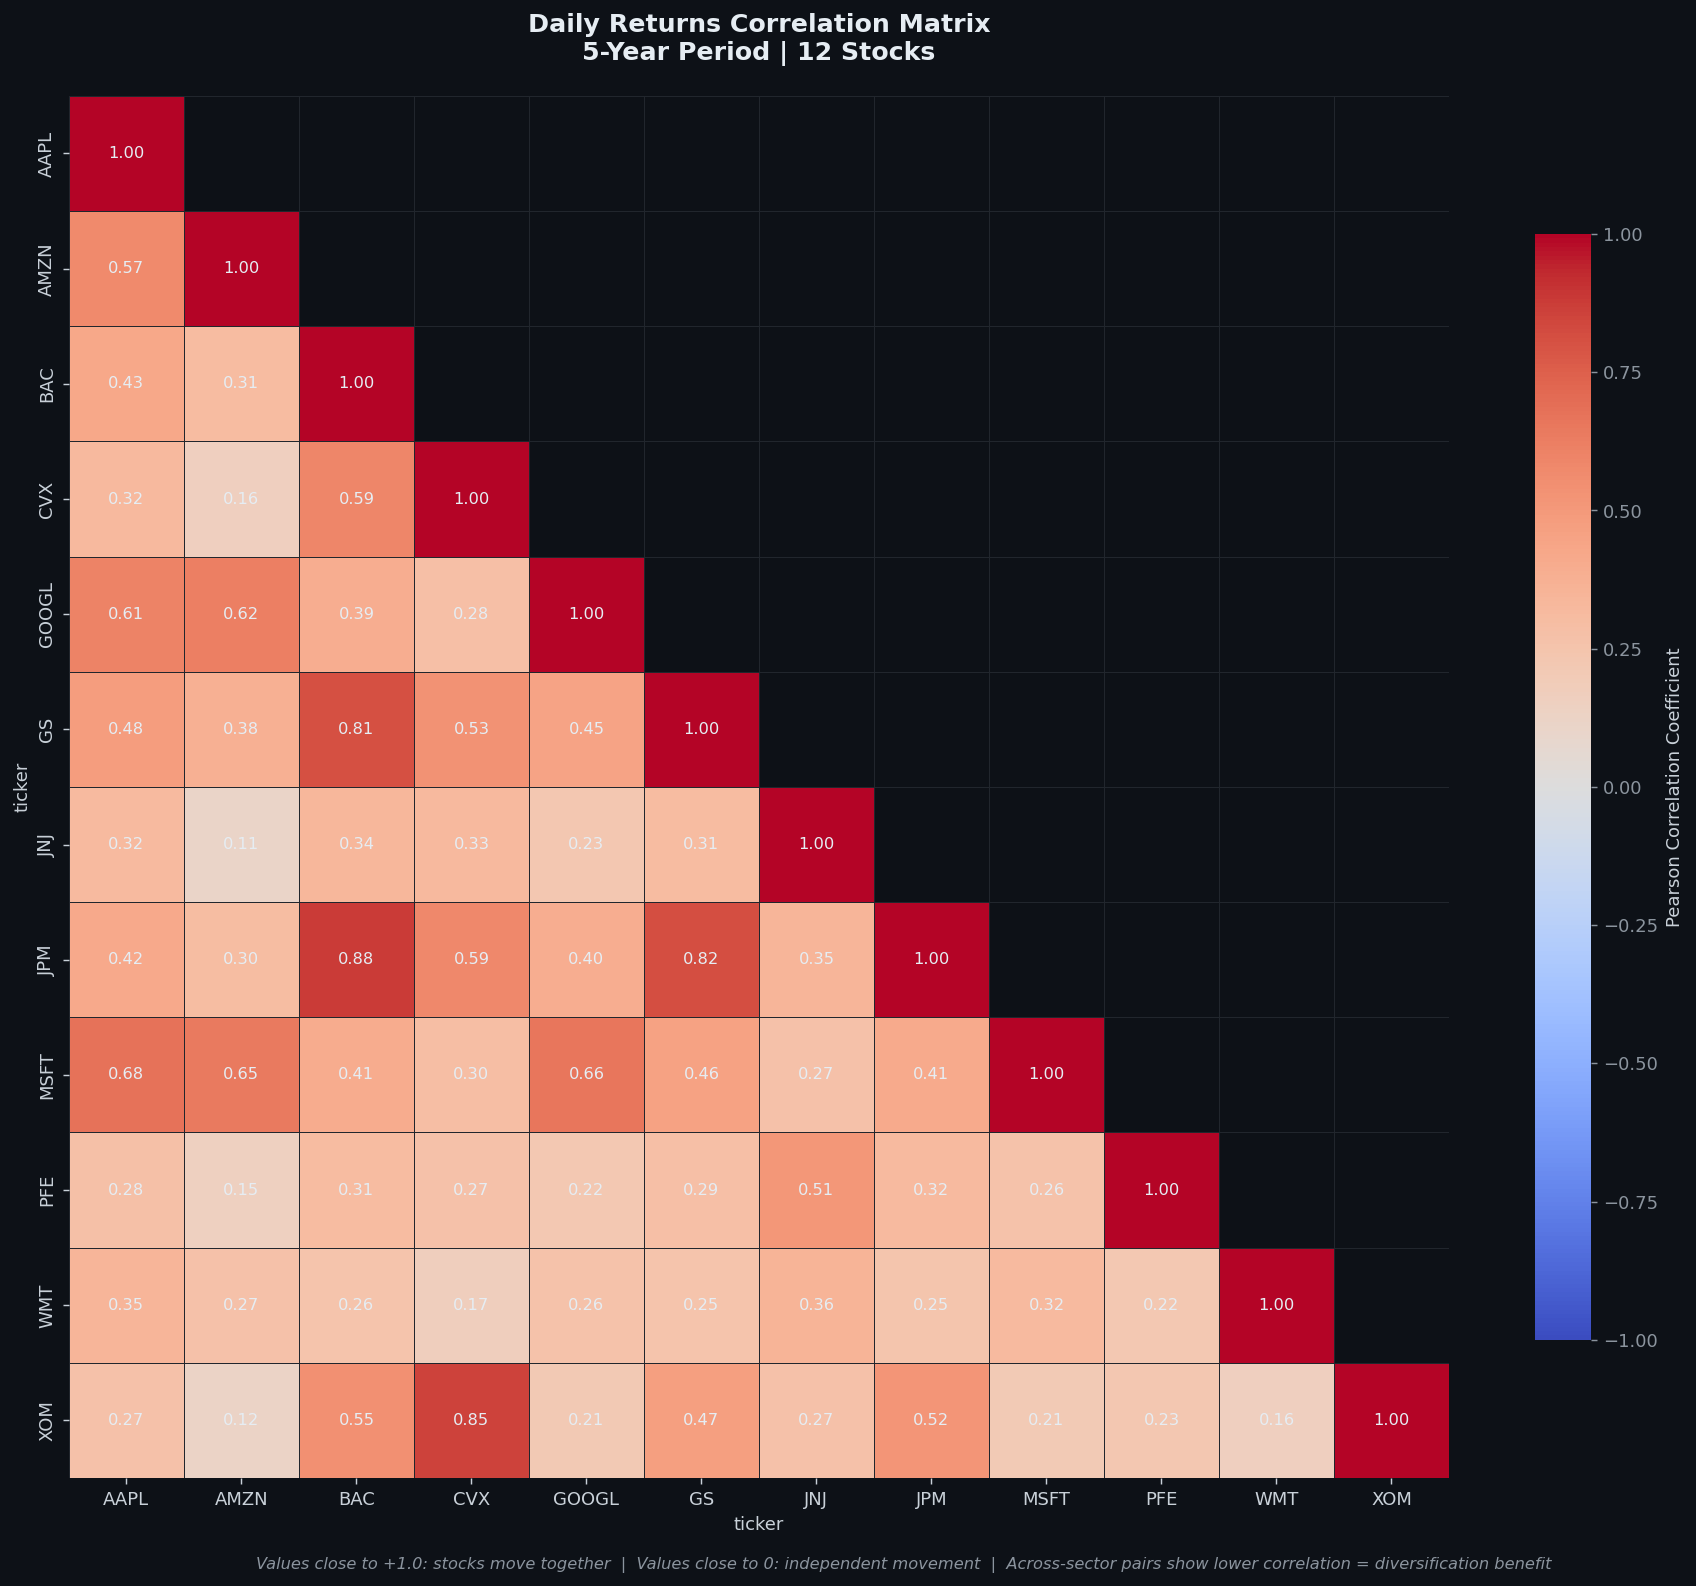


Highest correlated pairs (move together):
Stock_B Stock_A  Corr
    JPM     BAC 0.879
    XOM     CVX 0.855
    JPM      GS 0.818
     GS     BAC 0.805
   MSFT    AAPL 0.678

Lowest correlated pairs (best diversification):
Stock_B Stock_A  Corr
    CVX    AMZN 0.161
    XOM     WMT 0.158
    PFE    AMZN 0.152
    XOM    AMZN 0.122
    JNJ    AMZN 0.114


In [13]:
# CHART 4 — Daily Returns Correlation Matrix

returns_pivot = daily_df.pivot(
    index="date",
    columns="ticker",
    values="daily_return"
)
corr_matrix = returns_pivot.corr()

# Lower triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="#21262d",
    ax=ax,
    cbar_kws={"label": "Pearson Correlation Coefficient", "shrink": 0.8},
    annot_kws={"size": 9, "color": "#e6edf3"}
)

ax.set_title(
    "Daily Returns Correlation Matrix\n5-Year Period | 12 Stocks",
    fontsize=14, fontweight="bold", pad=20, color="#e6edf3"
)
ax.tick_params(colors="#c9d1d9", labelsize=10)

fig.text(
    0.5, -0.01,
    "Values close to +1.0: stocks move together  |  "
    "Values close to 0: independent movement  |  "
    "Across-sector pairs show lower correlation = diversification benefit",
    ha="center", fontsize=9, color="#8b949e", style="italic"
)

plt.tight_layout()
plt.savefig(
    "../reports/chart4_correlation_matrix.png",
    dpi=150, bbox_inches="tight", facecolor="#0d1117"
)
plt.show()

# Print top and bottom correlating pairs

corr_matrix.index.name = "Stock_A"
corr_matrix.columns.name = "Stock_B"

pairs = (
    corr_matrix.unstack()
    .rename("Corr")
    .reset_index()
)

pairs = (
    pairs[pairs["Stock_A"] < pairs["Stock_B"]]
    .sort_values("Corr", ascending=False)
)

pairs["Corr"] = pairs["Corr"].round(3)

print("\nHighest correlated pairs (move together):")
print(pairs.head(5).to_string(index=False))

print("\nLowest correlated pairs (best diversification):")
print(pairs.tail(5).to_string(index=False))

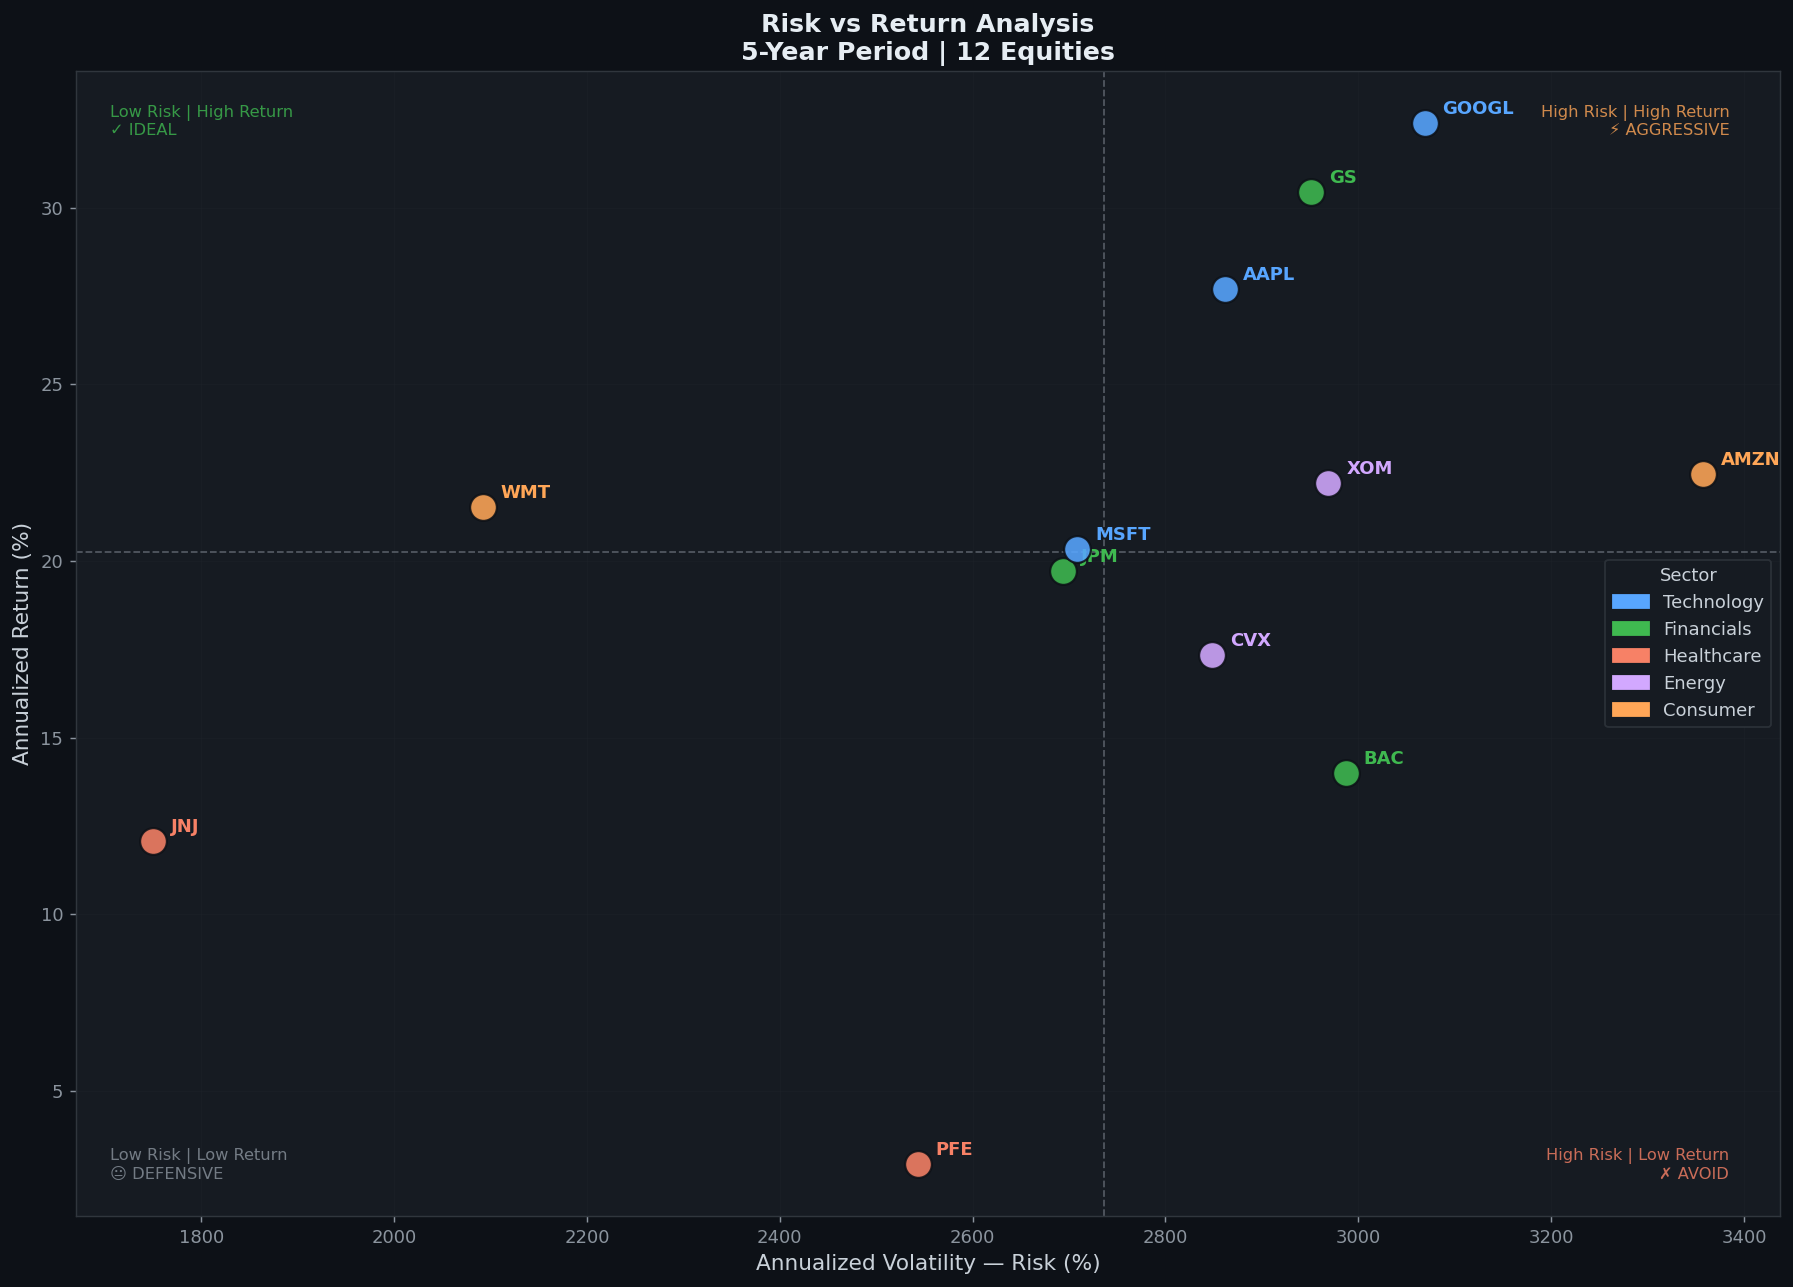


--- Risk vs Return Summary ---
ticker  annualized_return  annualized_vol     sector
 GOOGL          32.409417       30.687265 Technology
    GS          30.433888       29.510941 Financials
  AAPL          27.709383       28.614180 Technology
  AMZN          22.458794       33.574312   Consumer
   XOM          22.196861       29.690770     Energy
   WMT          21.531527       20.919956   Consumer
  MSFT          20.331667       27.082764 Technology
   JPM          19.715045       26.937362 Financials
   CVX          17.325014       28.479047     Energy
   BAC          13.994397       29.869849 Financials
   JNJ          12.065129       17.503709 Healthcare
   PFE           2.921481       25.429997 Healthcare


In [15]:
# CHART 5 — Risk vs Return Scatter Plot

# Quadrants:
# Top-left:     ideal — high return, low risk
# Top-right:    aggressive — high return, high risk
# Bottom-left:  defensive — low return, low risk
# Bottom-right: avoid — low return, high risk

summary = daily_df.groupby("ticker").agg(
    annualized_return  = ("daily_return",  lambda x: x.mean() * 252),
    annualized_vol     = ("volatility_ann","mean"),
    sector             = ("sector",        "first"),
).reset_index()

# Remove rows where volatility is NaN or zero
summary = summary[summary["annualized_vol"] > 0].copy()

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")

for _, row in summary.iterrows():
    color = SECTOR_COLORS.get(row["sector"], "#ffffff")

    ax.scatter(
        row["annualized_vol"] * 100,
        row["annualized_return"],
        color=color,
        s=220,
        alpha=0.88,
        edgecolors="#0d1117",
        linewidth=1.2,
        zorder=4
    )

    ax.annotate(
        row["ticker"],
        xy=(row["annualized_vol"] * 100, row["annualized_return"]),
        xytext=(10, 5),
        textcoords="offset points",
        fontsize=10,
        color=color,
        fontweight="bold"
    )

# Mean reference lines
mean_ret = summary["annualized_return"].mean()
mean_vol = (summary["annualized_vol"] * 100).mean()

ax.axhline(mean_ret, color="#8b949e", linestyle="--", alpha=0.5, linewidth=1)
ax.axvline(mean_vol, color="#8b949e", linestyle="--", alpha=0.5, linewidth=1)

# Quadrant labels
ax.text(0.02, 0.97, "Low Risk | High Return\n✓ IDEAL",
        transform=ax.transAxes, color="#3fb950",
        fontsize=9, va="top", alpha=0.8)
ax.text(0.97, 0.97, "High Risk | High Return\n⚡ AGGRESSIVE",
        transform=ax.transAxes, color="#ffa657",
        fontsize=9, va="top", ha="right", alpha=0.8)
ax.text(0.02, 0.03, "Low Risk | Low Return\n😐 DEFENSIVE",
        transform=ax.transAxes, color="#8b949e",
        fontsize=9, va="bottom", alpha=0.8)
ax.text(0.97, 0.03, "High Risk | Low Return\n✗ AVOID",
        transform=ax.transAxes, color="#f78166",
        fontsize=9, va="bottom", ha="right", alpha=0.8)

# Legend
legend_patches = [
    mpatches.Patch(color=v, label=k)
    for k, v in SECTOR_COLORS.items()
]
ax.legend(
    handles=legend_patches, fontsize=10,
    title="Sector", title_fontsize=10, loc="center right"
)

ax.set_xlabel("Annualized Volatility — Risk (%)",  fontsize=12, color="#c9d1d9")
ax.set_ylabel("Annualized Return (%)",             fontsize=12, color="#c9d1d9")
ax.set_title(
    "Risk vs Return Analysis\n5-Year Period | 12 Equities",
    fontsize=14, fontweight="bold", color="#e6edf3"
)
ax.grid(True, alpha=0.3)
ax.tick_params(colors="#8b949e")

plt.tight_layout()
plt.savefig(
    "../reports/chart5_risk_return.png",
    dpi=150, bbox_inches="tight", facecolor="#0d1117"
)
plt.show()

print("\n--- Risk vs Return Summary ---")
print(summary.sort_values("annualized_return", ascending=False).to_string(index=False))